In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
import pyleoclim as pyleo
# from pyleoclim.utils.wavelet import cwt_coherence
# import scipy.signal as ss
# from scipy.interpolate import PchipInterpolator, interp1d
from pipeline import *

In [ ]:
# for tr in transitions:
#     print(
#         f"Transition at t={tr['time']:.3f}s | "
#         f"{tr['from_state']} -> {tr['to_state']} | "
#         f"jump={np.degrees(tr['phase_jump']):.1f} deg | "
#         f"std={tr['std']:.3f} | "
#         f"start={tr['duration']['start']} , end={tr['duration']['end']} | "
#         # f"type: {type(tr['duration']['start'])} | "
#         f"duration={tr['duration']['length']:.3f} , {tr['duration']['state']}"
#     )

In [ ]:
# # # Load data
# df = pd.read_excel("data/am0324_analysis/20260324_buntingphysio_bunt_am0324.xlsx")
# df

In [ ]:
# ####INTERPOLATE data####
# time_col = "time"
# angle_cols = ["p1_unwrapped", "p2_unwrapped"]
# current_cols = ["i1", "i2"]

# # 1) sort + collapse duplicate timestamps
# df = df.sort_values(time_col)
# df = df.groupby(time_col, as_index=False).mean()

# # extract columns
# cosxpi = df["time"].to_numpy() 
# p1_angle = df["p1"].to_numpy()
# p2_angle = df["x"].to_numpy()
# # i1 = df["i1"].to_numpy()
# # i2 = df["i2"].to_numpy()
# # p1 = df["p1"].to_numpy()
# # p2 = df["p2"].to_numpy()

# # 2) unwrap
# p1_unwrapped = np.unwrap(p1_angle-np.pi)#+np.pi 
# p2_unwrapped = np.unwrap(p2_angle-np.pi)#+np.pi

# #add unwrapped columns to df
# df["p1_unwrapped"] = p1_unwrapped
# df["p2_unwrapped"] = p2_unwrapped

# # 3) make uniform 0.001s grid
# dt_target = 0.001
# t_new = np.arange(cosxpi.min(), cosxpi.max() + dt_target/2, dt_target)

# # 4) interpolate angles (PCHIP is shape-preserving)
# out = {time_col: t_new}

# for c in angle_cols:
#     cosx = df[c].to_numpy()
#     out[c] = PchipInterpolator(cosxpi, cosx)(t_new)

# # 5) interpolate currents (linear)
# for c in current_cols:
#     cosx = df[c].to_numpy()
#     out[c] = interp1d(cosxpi, cosx, kind="linear", bounds_error=False, fill_value="extrapolate")(t_new)

# df_rs = pd.DataFrame(out)

# # extract resampled columns
# t_rs = df_rs[time_col].to_numpy()
# p1_unwrapped_rs = df_rs["p1_unwrapped"].to_numpy()
# p2_unwrapped_rs = df_rs["p2_unwrapped"].to_numpy()
# i1_rs = df_rs["i1"].to_numpy()
# i2_rs = df_rs["i2"].to_numpy()

# # 6) compute torque + velocity
# df_rs["torque1"] = df_rs["i1"] * 0.011
# df_rs["torque2"] = df_rs["i2"] * 0.011

# df_rs["omega1"] = np.gradient(df_rs["p1_unwrapped"].to_numpy(), dt_target)
# df_rs["omega2"] = np.gradient(df_rs["p2_unwrapped"].to_numpy(), dt_target)


In [ ]:
# fig, axs = plt.subplots(1, 1, figsize=(40, 10))
# axs.plot(t_rs, np.cos(p1_unwrapped_rs), label="time vs p1 angle")
# axs.plot(t_rs, np.cos(p2_unwrapped_rs), label="time vs p1 angle")
# plt.legend(fontsize=20)
# plt.xlabel("time", fontsize=20)
# plt.ylabel("angle (rad)", fontsize=20)
# plt.grid(True)
# # plt.xticks(np.arange(0, 4000, 100))

In [ ]:
# divide_by_trials(df)

In [ ]:
df_processed, phase_windows, transitions, transition_summary = run_full_pipeline(
    "data/am0324_analysis/20260324_buntingphysio_bunt_am0324.xlsx",
    "data/am0324_analysis/20260324_buntingphysio_physio_am0324.xlsx",
    3200,
    # 3288-30,
    3250,
    dt=1/114,
    window_size=0.2,
    freq_band=(0.1, 100),
    phase_jump_thresh=np.deg2rad(50),
    smooth_k=3,
    min_dwell=4,
)
"""
nc0304:
static practice: 1191.377166, 1292.866931: 101.48976500000003
slow practice: 1337.248022, 1438.3563219999999: 101.10829999999987
fast practice:1438.368602, 1534.6634119999999: 96.29480999999987
follower: 1770.759811, 2036.678639: 265.9188280000001
evolved: 2365.8661429999997, 2688.2532429999997: 322.3870999999999
independant: 2959.679343, 3288.409335: 328.72999200000004
human-human: 3507.798812, 3852.502728: 344.70391599999994
"""

In [ ]:
# # Sampling interval and sampling rate
# dt = np.diff(df_processed["time"]).mean()   # sec/sample
# fs = int(round(1 / dt))                     # Hz, make sure it's an integer

# # ---------------- PPG ----------------
# ppg_raw = df_processed["pulse_raw"].to_numpy()

# ppg_signals, ppg_info = nk.ppg_process(ppg_raw, sampling_rate=fs)

# nk.ppg_plot(ppg_signals, ppg_info)
# fig = plt.gcf()
# fig.set_size_inches(10, 12, forward=True)
# plt.show()

# print(nk.ppg_intervalrelated(ppg_signals, sampling_rate=fs))

# nk.hrv(ppg_signals["PPG_Peaks"], sampling_rate=fs, show=True)
# fig = plt.gcf()
# fig.set_size_inches(16, 6, forward=True)
# plt.show()

# # Optional BPM output
# print("Mean BPM:", np.nanmean(ppg_signals["PPG_Rate"]))

# # ---------------- EDA ----------------
# eda_raw = df_processed["gsr_raw"].to_numpy()

# eda_signals, eda_info = nk.eda_process(eda_raw, sampling_rate=fs)

# nk.eda_plot(eda_signals, eda_info)
# fig = plt.gcf()
# fig.set_size_inches(10, 12, forward=True)
# plt.show()

# eda_summary = nk.eda_intervalrelated(eda_signals, sampling_rate=fs)
# print(eda_summary)

# print("SCR count:", int(eda_signals["SCR_Peaks"].sum()))

In [ ]:
df_processed

In [ ]:
# plot_bmp(df_processed, transitions, transition_summary)

In [ ]:
# compute_bpm_diff(transitions)

In [ ]:
# plot_bpms_strip(transition_summary)

In [ ]:
# results_df = pairwise_independent_ttests(transition_summary["bpms"])
# print(results_df.round(3))

In [ ]:
# # plot_angles(
# #     df_processed["time"],
# #     df_processed["p1_unwrapped"],
# #     df_processed["p2_unwrapped"],
# # )

# # plot_angular_velocity(
# #     df_processed["time"],
# #     df_processed["omega1"],
# #     df_processed["omega2"],
# # )

# # plot_windowed_phase(phase_windows)
# # plot_windowed_correlation(phase_windows)
# plot_phase_transitions(transition_summary, transitions, df_processed)


In [ ]:
# for tr in transitions:
#     print(
#         f"Transition at t={tr['time']:.3f}s | "
#         f"{tr['from_state']} -> {tr['to_state']} | "
#         f"jump={np.degrees(tr['phase_jump']):.1f} deg | "
#         f"std={tr['std']:.3f} | "
#         f"start={tr['duration']['start']} , end={tr['duration']['end']} | "
#         # f"type: {type(tr['duration']['start'])} | "
#         f"duration={tr['duration']['length']:.3f} , {tr['duration']['state']}"
#     )

In [ ]:
# # plot_transition_bar(transitions)
# plot_transition_types(transitions)
# # plot_transition_histogram(transitions)
# plot_state_histogram(transitions)
# # plot_bpms_strip(transitions_summary)

In [ ]:
# plot_transition_diagnostics(
#     transition_summary,
#     phase_windows,
#     transitions=transitions,
#     min_dwell=5,
# )

In [ ]:
# # 1) check raw sliced data before resampling
# df_raw = load_and_clean_data("data/nc0304_pilot_data_truncated.xlsx")
# df = divide_data(df_raw, 3507+30, 3507+60)

# print(df[["time", "angle_p1", "angle_p2", "i1", "i2"]].isna().sum())

# # 2) check after unwrap + resample
# df_u = unwrap_angles(df.copy())
# df_rs = resample_signals(df_u, dt_target=1/114)

# print(df_rs[["p1_unwrapped", "p2_unwrapped", "i1", "i2"]].isna().sum())

# # 3) check which windows are bad
# bad = []
# for i, w in enumerate(phase_windows):
#     if np.isnan(w["mean"]) or np.isnan(w["std"]):
#         bad.append(i)

# print("bad windows:", bad[:20], "count=", len(bad))

# # 4) inspect one bad window
# i = bad[0]
# w = phase_windows[i]
# print("window", i, "start", w["start"], "end", w["end"])
# print("phi_wrapped NaNs:", np.isnan(w["phi_wrapped"]).sum())
# print("phi_wrapped len:", len(w["phi_wrapped"]))

Verification:

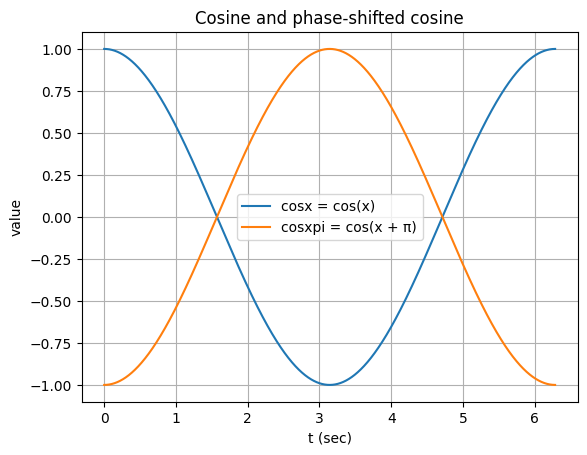

In [2]:
# x domain (radians)
x = np.linspace(0, 2*np.pi, 3894676)

# signals
cosx = np.cos(x)              # y = cos(x)
cosxpi = np.cos(x + np.pi)      # z = cos(x + pi) = -cos(x)
sh = np.cos(x +1/2*np.pi) 
sc = np.cos(x/2) 
c = 0.5
c_sig = np.full_like(x, c)

# plot
plt.figure()
plt.plot(x, cosx, label="cosx = cos(x)")
plt.plot(x, cosxpi, label="cosxpi = cos(x + π)")
# plt.plot(x, sh, label="sh = cos(x + 1/2*π)")
# plt.plot(x, sc, label="sc = cos(x/2)")
# plt.plot(x, c_sig, label="c = 0.5")   # constant line
plt.xlabel("t (sec)")
plt.ylabel("value")
plt.title("Cosine and phase-shifted cosine")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:

# window_size=0.5
# freq_band = (0, 100)
# phase_jump_thresh = np.deg2rad(45)
# smooth_k=3
# min_dwell=2

# windows = windowed_phase_analysis(
#     cosx,
#     cosxpi,
#     t_rs,
#     window_size=window_size,
#     freq_band=freq_band,
# )

# transitions, transition_summary = detect_phase_transitions(
#     windows,
#     phase_jump_thresh=phase_jump_thresh,
#     smooth_k=smooth_k,
#     min_dwell=min_dwell,
# )

In [2]:

df_processed, phase_windows, transitions, transition_summary = test_pipeline(
    "data/simulated_cos_data_shifted.xlsx",
    0,
    2900,
    dt=1/114,
    window_size=0.5,
    freq_band=(0, 100),
    phase_jump_thresh=np.deg2rad(45),
    smooth_k=3,
    min_dwell=2,
)

['time', 'angle_p1', 'angle_p2', 'i1', 'i2', 'p1', 'p2']
[]
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.27138348 57.        ], nfreq=6
Setting freq=[2.03571429 3.96413495 7.71933763]...[15.03182265 29.2

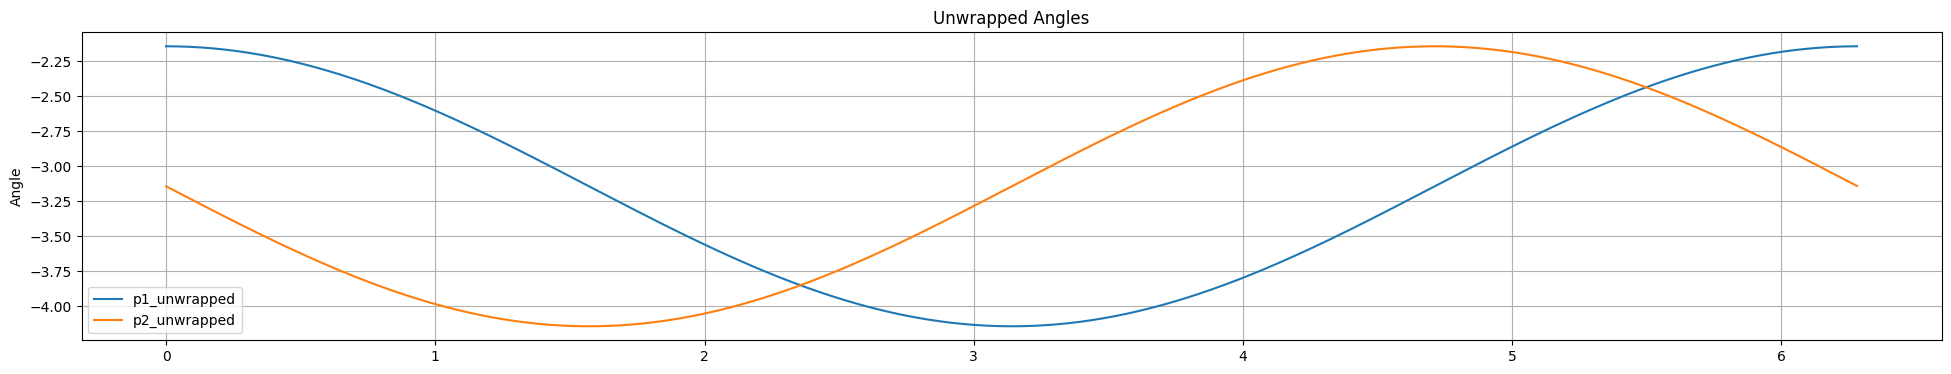

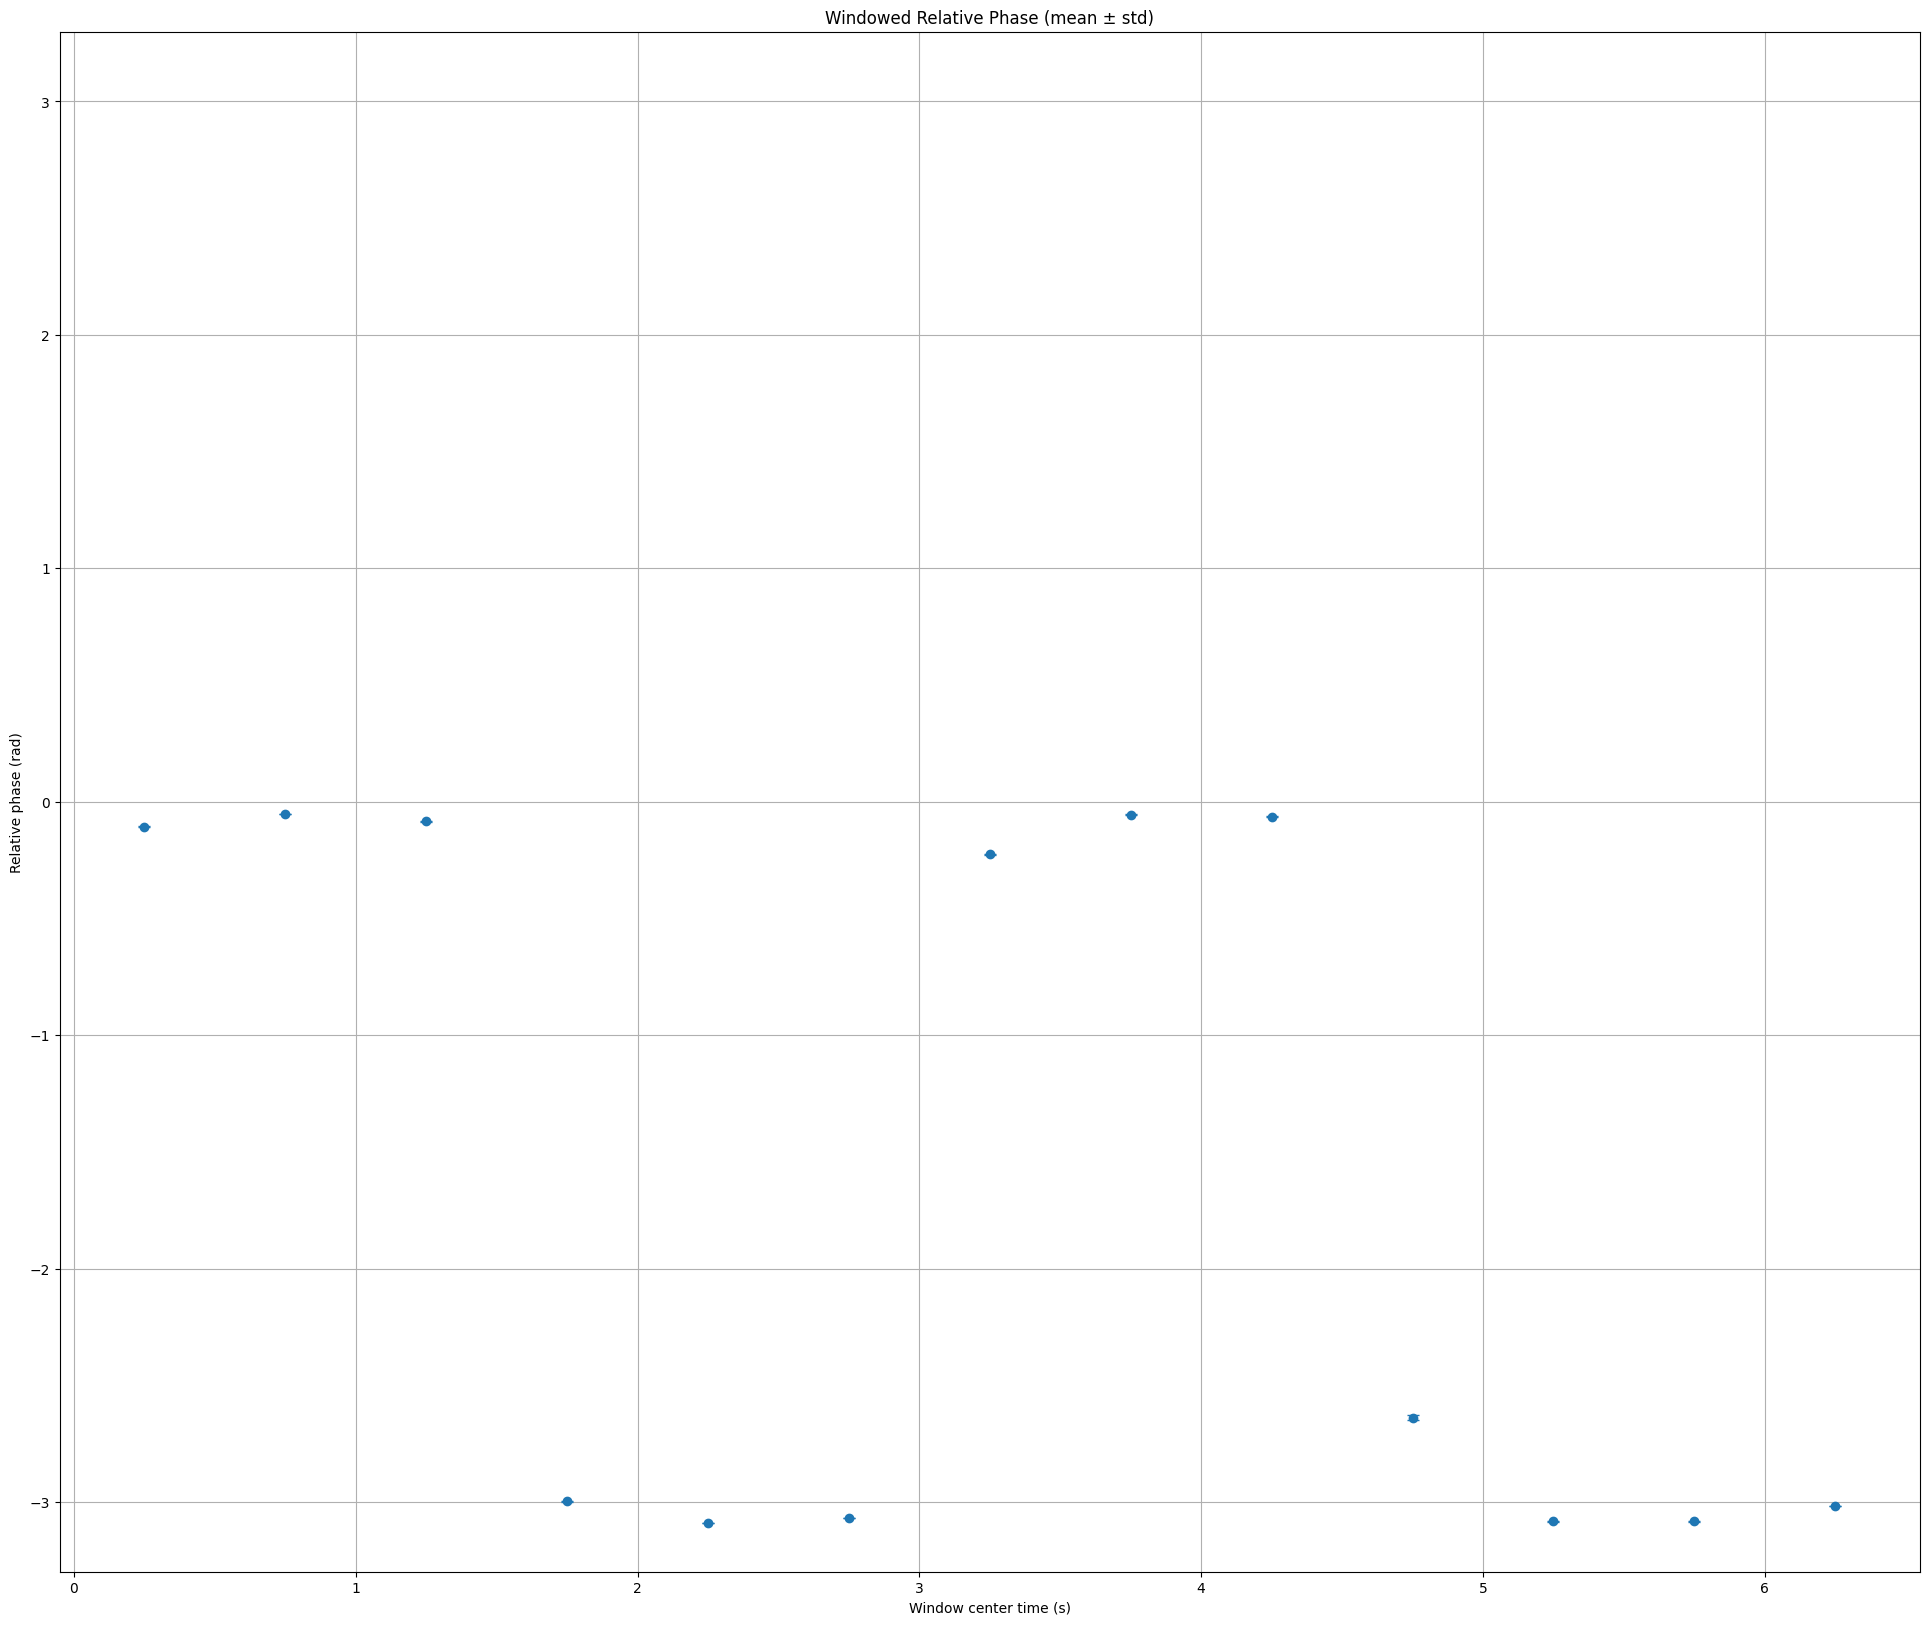

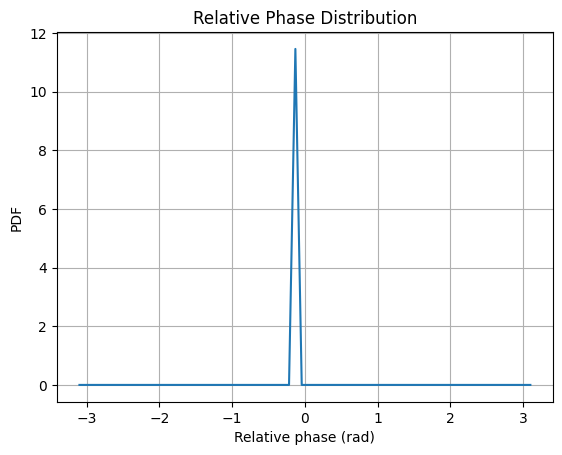

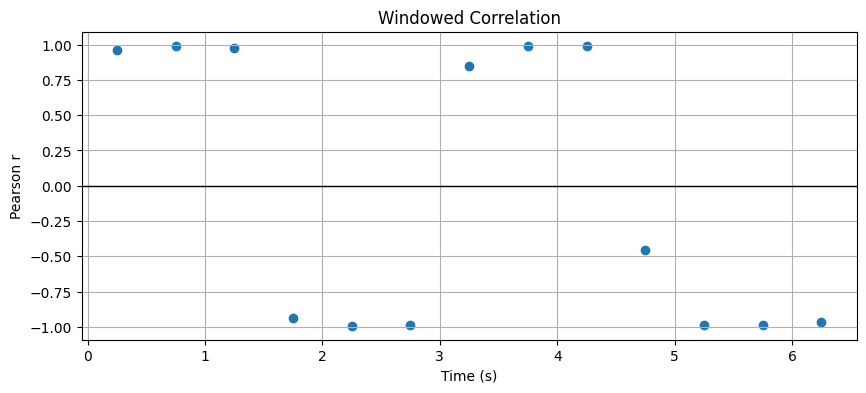

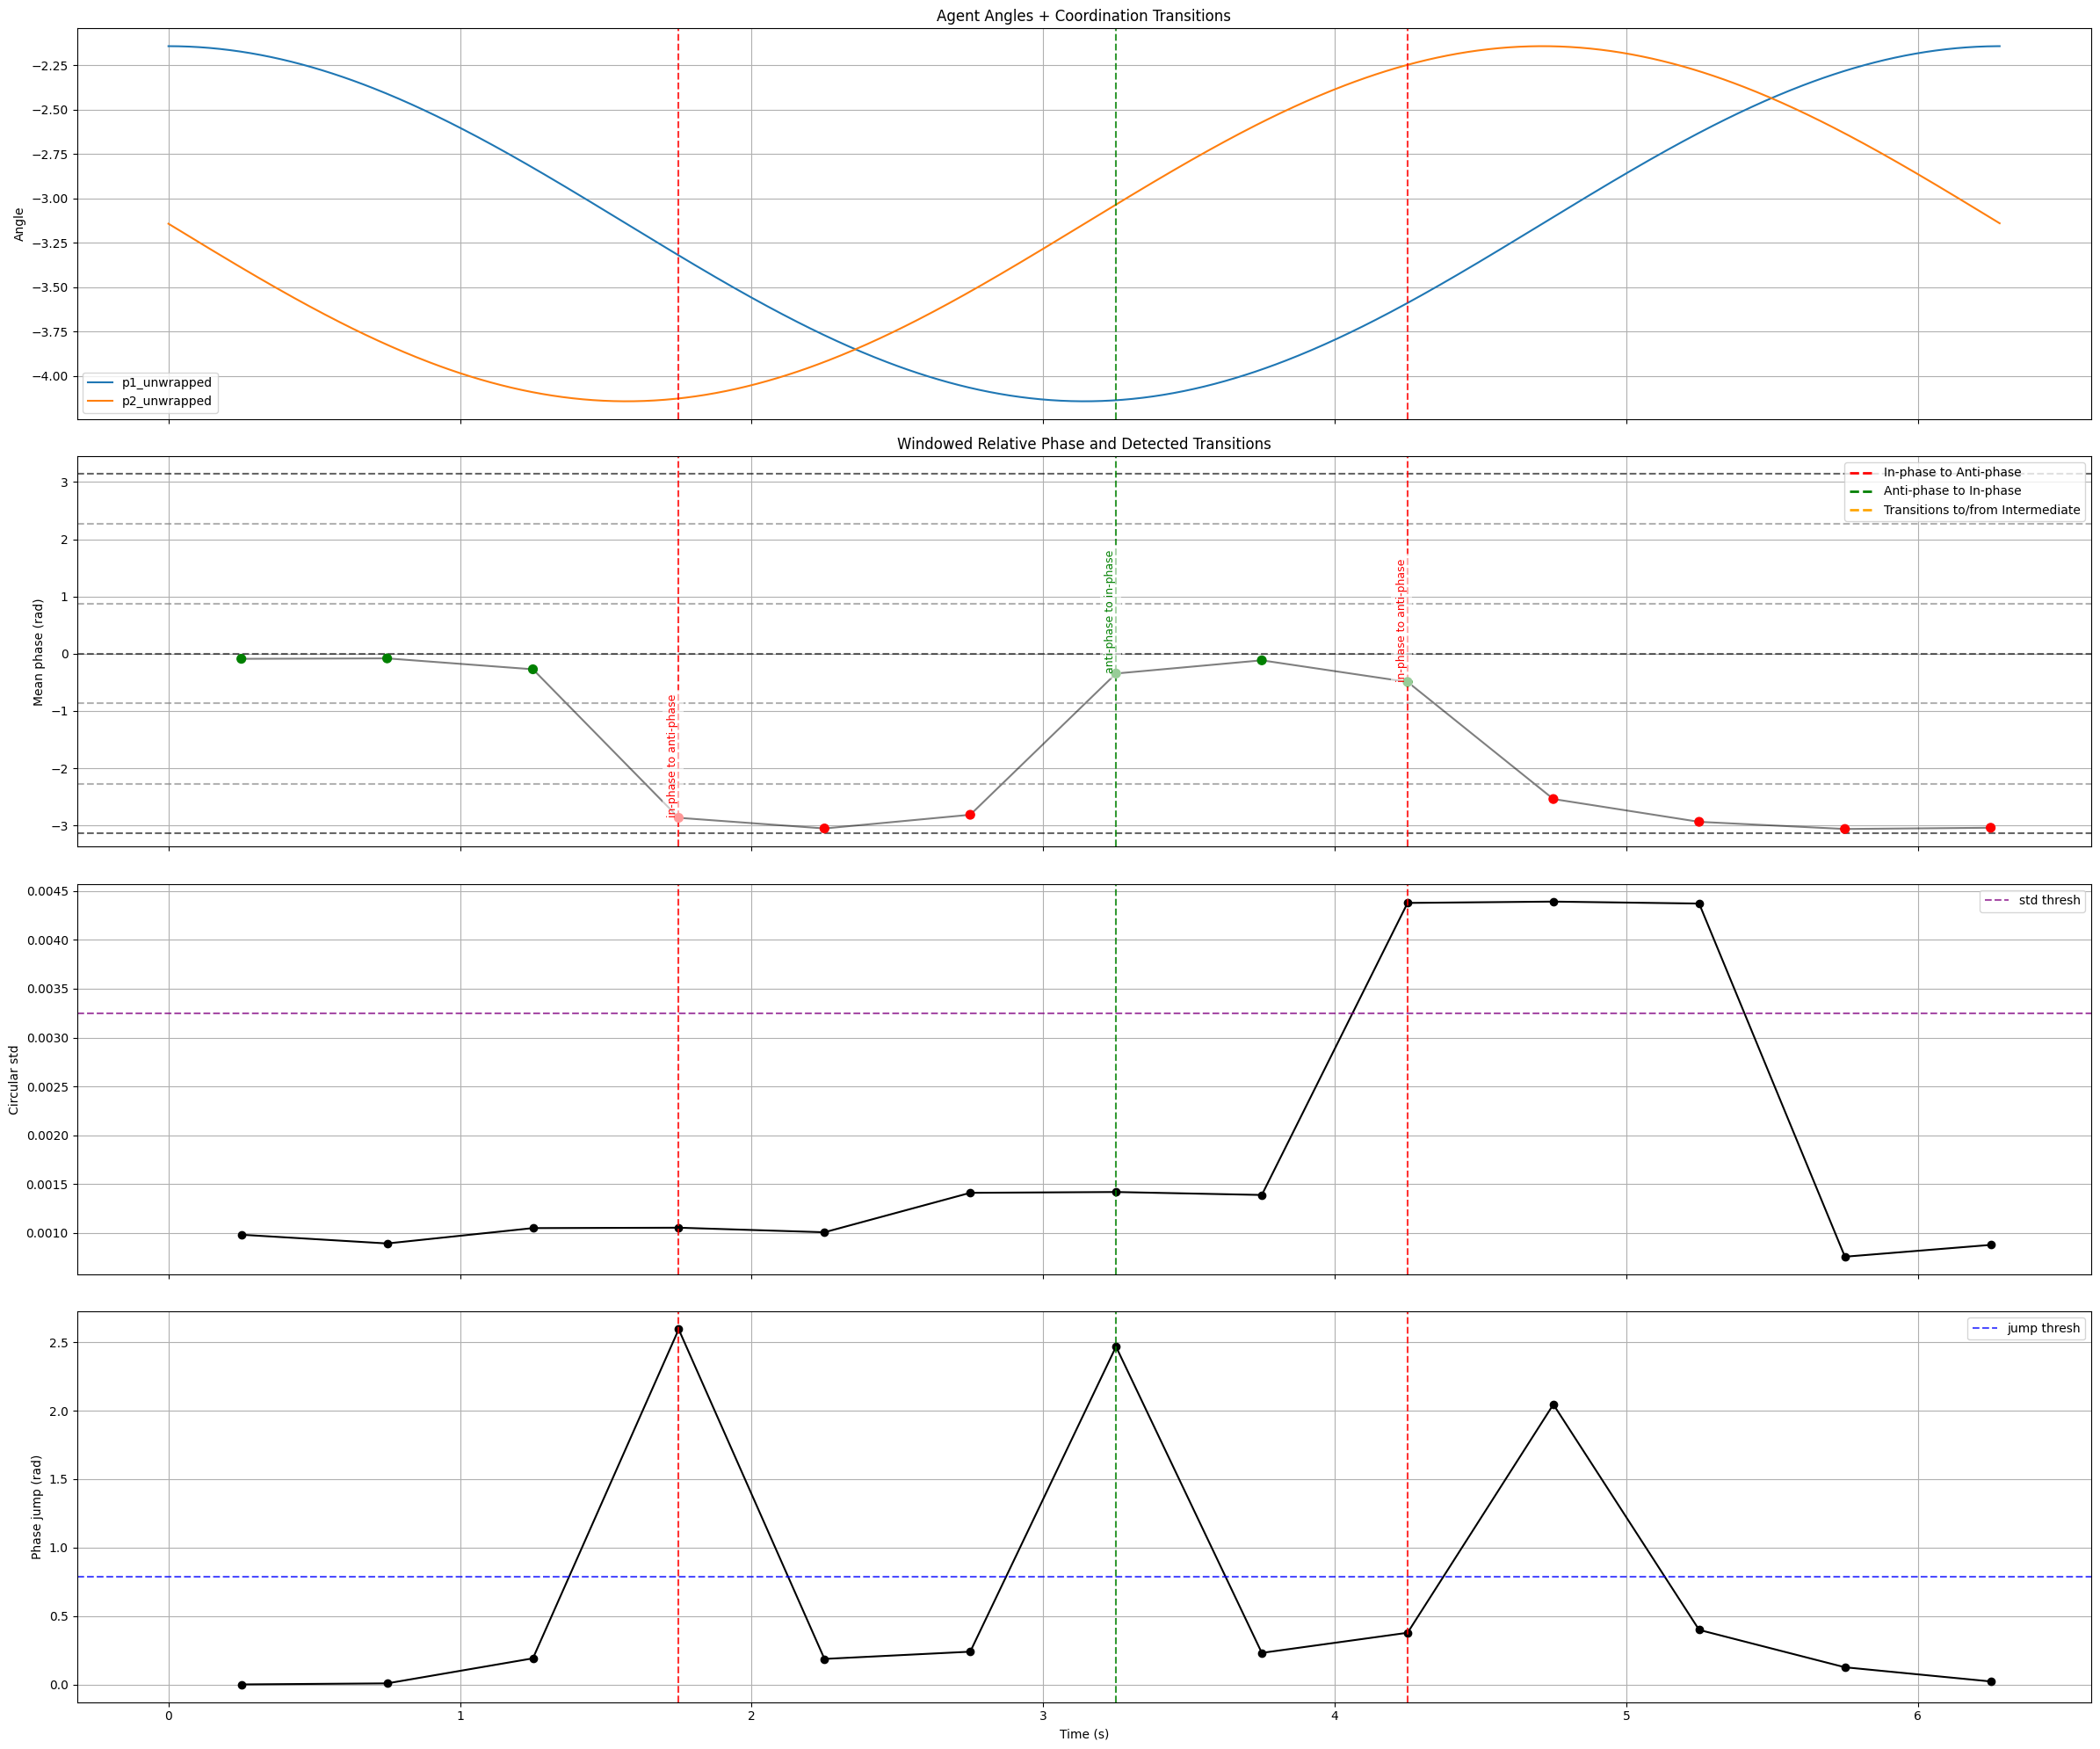

Transition at t=1.750s | in-phase -> anti-phase | jump=148.6 deg | std=0.001
Transition at t=3.250s | anti-phase -> in-phase | jump=141.4 deg | std=0.001
Transition at t=4.250s | in-phase -> anti-phase | jump=21.6 deg | std=0.004


In [3]:
plot_angles(
    df_processed["time"],
    df_processed["p1_unwrapped"],
    df_processed["p2_unwrapped"],
)

# plot_angular_velocity(
#     df_processed["time"],
#     df_processed["omega1"],
#     df_processed["omega2"],
# )

plot_windowed_phase(phase_windows)
plot_windowed_correlation(phase_windows)
plot_phase_transitions(transition_summary, transitions, df_processed)

for tr in transitions:
    print(
        f"Transition at t={tr['time']:.3f}s | "
        f"{tr['from_state']} -> {tr['to_state']} | "
        f"jump={np.degrees(tr['phase_jump']):.1f} deg | "
        f"std={tr['std']:.3f}"
    )

In [ ]:
# plot_transition_bar(transitions)
plot_transition_types(transitions)
plot_transition_histogram(transitions)